In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

2024-12-26 16:59:25.629550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735212565.640588  220779 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735212565.643974  220779 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-26 16:59:25.658230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 各パス指定

In [2]:
dataset = 'hand_gesture/model/keypoint_classifiers/keypoint.csv'
model_save_path = '/home/divya/PycharmProjects/SmartSentinel/hand_gesture/model/keypoint_classifiers/keypoint_classifier.keras'

# 分類数設定

In [3]:
NUM_CLASSES = 3

# 学習データ読み込み

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

I0000 00:00:1735212567.734016  220779 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1082 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103 (4.31 KB)

 Trainable params: 1,103 (4.31 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


I0000 00:00:1735212568.680788  220866 service.cc:148] XLA service 0x7fda84005660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1735212568.680833  220866 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2024-12-26 16:59:28.700787: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1735212568.773495  220866 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1953 - loss: 1.2032

I0000 00:00:1735212569.897219  220866 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.2217 - loss: 1.1869
Epoch 1: saving model to /home/divya/PycharmProjects/SmartSentinel/hand_gesture/model/keypoint_classifiers/keypoint_classifier.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.2236 - loss: 1.1858 - val_accuracy: 0.2827 - val_loss: 1.0902
Epoch 2/1000
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2812 - loss: 1.1295
Epoch 2: saving model to /home/divya/PycharmProjects/SmartSentinel/hand_gesture/model/keypoint_classifiers/keypoint_classifier.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2919 - loss: 1.1205 - val_accuracy: 0.4982 - val_loss: 1.0406
Epoch 3/1000
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3828 - loss: 1.0966
Epoch 3: saving model to /home/divya/PycharmProjects/SmartSentinel/hand_gesture/model/keypoint_classifiers/keypoint_classifier.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3803 - loss: 1.0878 - val_accuracy: 0.6608 - val_loss: 0.9987
Epoch 4/1000
1/

In [12]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9538 - loss: 0.1887 


In [13]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
[2.7313698e-04 2.6402771e-04 9.9946290e-01]
2


# 混同行列

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


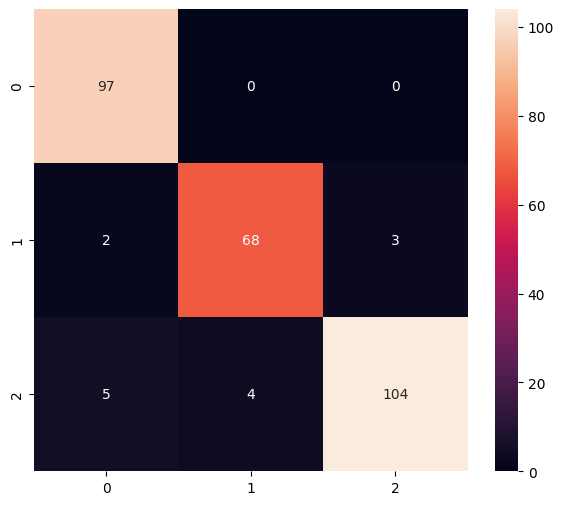

Classification Report
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        97
           1       0.94      0.93      0.94        73
           2       0.97      0.92      0.95       113

    accuracy                           0.95       283
   macro avg       0.95      0.95      0.95       283
weighted avg       0.95      0.95      0.95       283



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [16]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

In [17]:
# モデルを変換(量子化)
tflite_save_path = '/media/divya/OS/Users/Divya M/anaconda3/envs/mediapipe_env/hand-gesture-recognition-mediapipe-main/model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmpqo___tif/assets


INFO:tensorflow:Assets written to: /tmp/tmpqo___tif/assets


Saved artifact at '/tmp/tmpqo___tif'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140580655805216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140581192499264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580655805040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580655915680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580655920784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580655919904: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1735212584.552740  220779 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1735212584.552754  220779 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2024-12-26 16:59:44.552973: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqo___tif
2024-12-26 16:59:44.553375: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2024-12-26 16:59:44.553385: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpqo___tif
I0000 00:00:1735212584.556250  220779 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2024-12-26 16:59:44.556745: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2024-12-26 16:59:44.572329: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpqo___tif
2024-12-26 16:59:44.576755: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

6512

# 推論テスト

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [19]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 156 μs, sys: 23 μs, total: 179 μs
Wall time: 124 μs


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[2.7313695e-04 2.6402745e-04 9.9946290e-01]
2
